# Classical CNN Baseline — Concrete Crack Classification
**Like-for-like counterpart to the Hybrid QCNN notebook.**

The ONLY architectural difference is the quantum circuit replaced by a small classical MLP.
Everything else — data, preprocessing, split, seeds, hyperparameters, evaluation — is identical.


In [1]:
## 1. Setup — paths, imports, seeds, device

import sys
import random
import time
import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# ── project root detection (same logic as QCNN notebook) ──────────────────
cwd = Path.cwd().resolve()
if (cwd / 'src').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'src').exists():
    PROJECT_ROOT = cwd.parent
elif (cwd.parent.parent / 'src').exists():
    PROJECT_ROOT = cwd.parent.parent
else:
    PROJECT_ROOT = cwd

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

DATASET_ROOT = PROJECT_ROOT / 'raw_classification'
RANDOM_SEED  = 42

print('Project root :', PROJECT_ROOT)
print('Dataset root :', DATASET_ROOT)
print('Dataset exists:', DATASET_ROOT.exists())


Project root : /Users/anton/Documents/GitHub/Final_Year_Project
Dataset root : /Users/anton/Documents/GitHub/Final_Year_Project/raw_classification
Dataset exists: True


In [2]:
## 2. Read config — all values from source, nothing hardcoded

from quantum_cnn.config import QuantumCNNConfig

# These are the values used in the QCNN notebook (not the dataclass defaults)
config = QuantumCNNConfig(
    dataset_root=str(DATASET_ROOT),
    image_size=32,
    batch_size=32,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    learning_rate=1e-3,
    weight_decay=1e-4,
    epochs=8,
    seed=RANDOM_SEED,
    n_qubits=4,
    n_q_layers=2,
    quantum_embedding_dim=8,
    hidden_dim=64,
    max_train_samples=7000,
    max_val_samples=1500,
    max_test_samples=1500,
    output_root=str(PROJECT_ROOT / 'runs' / 'quantum_cnn'),
    experiment_name='notebook_run',
)

print('──── Configuration (must match QCNN notebook exactly) ────')
for k, v in config.to_dict().items():
    print(f'  {k:<30} {v}')


──── Configuration (must match QCNN notebook exactly) ────
  dataset_root                   /Users/anton/Documents/GitHub/Final_Year_Project/raw_classification
  image_size                     32
  batch_size                     32
  train_ratio                    0.7
  val_ratio                      0.15
  test_ratio                     0.15
  seed                           42
  max_train_samples              7000
  max_val_samples                1500
  max_test_samples               1500
  quantum_preprocess             True
  use_grayscale                  True
  use_clahe                      True
  use_blackhat                   False
  learning_rate                  0.001
  weight_decay                   0.0001
  epochs                         8
  n_qubits                       4
  n_q_layers                     2
  quantum_embedding_dim          8
  hidden_dim                     64
  output_root                    /Users/anton/Documents/GitHub/Final_Year_Project/runs/quantum_cn

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [3]:
## 3. Inspect HybridQuantumCNN & quantum layer being replaced

from quantum_cnn.hybrid_qcnn import HybridQuantumCNN
from quantum_cnn.quantum_layer import QuantumCircuitLayer

qcnn_ref = HybridQuantumCNN(
    num_classes=2,
    n_qubits=config.n_qubits,
    n_q_layers=config.n_q_layers,
    quantum_embedding_dim=config.quantum_embedding_dim,
    hidden_dim=config.hidden_dim,
)
print('── HybridQuantumCNN architecture ──')
print(qcnn_ref)
print()

q_params = sum(p.numel() for p in qcnn_ref.parameters() if p.requires_grad)
ql_params = sum(p.numel() for p in qcnn_ref.quantum_layer.parameters() if p.requires_grad)
print(f'QCNN total trainable params  : {q_params:,}')
print(f'  of which in quantum_layer  : {ql_params:,}')
print()
print(f'Quantum circuit interface:')
print(f'  Input to quantum_input     : 3×4×4 = 48 (pooled image)')
print(f'  Embedding dim (→ qubits)   : {config.quantum_embedding_dim} → {config.n_qubits}')
print(f'  Qubits                     : {config.n_qubits}')
print(f'  Circuit layers             : {config.n_q_layers}')
print(f'  Output (Pauli-Z exp vals)  : {config.n_qubits}  (range [-1, +1])')
print(f'  quantum_layer theta shape  : [{config.n_q_layers}, {config.n_qubits}, 2]  = {config.n_q_layers * config.n_qubits * 2} params')


── HybridQuantumCNN architecture ──
HybridQuantumCNN(
  (classical_branch): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): AdaptiveAvgPool2d(output_size=(4, 4))
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=512, out_features=64, bias=True)
    (8): ReLU(inplace=True)
  )
  (quantum_input): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(4, 4))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=48, out_features=8, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
  (quantum_layer): QuantumCircuitLayer(
    (quantum_layer): <Quantum Torch Layer: func=_circuit>
  )
  (quantum_projection): Sequential(
    (0): Linear(in_features=4, out

In [4]:
## 4. Build ClassicalCNNBaseline & compare parameter counts

from quantum_cnn.classical_baseline import ClassicalCNNBaseline, print_param_comparison, count_parameters

baseline_model = ClassicalCNNBaseline(
    num_classes=2,
    quantum_embedding_dim=config.quantum_embedding_dim,
    hidden_dim=config.hidden_dim,
)
print('── ClassicalCNNBaseline architecture ──')
print(baseline_model)
print()

print_param_comparison(qcnn_ref, baseline_model)

q_total = count_parameters(qcnn_ref)
c_total = count_parameters(baseline_model)
delta_pct = abs(q_total - c_total) / q_total * 100
if delta_pct > 10:
    print(f'⚠️  Parameter counts differ by {delta_pct:.1f}% (> 10%) — check architecture.')
else:
    print(f'✅ Parameter counts within {delta_pct:.1f}% of each other.')


── ClassicalCNNBaseline architecture ──
ClassicalCNNBaseline(
  (classical_branch): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): AdaptiveAvgPool2d(output_size=(4, 4))
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=512, out_features=64, bias=True)
    (8): ReLU(inplace=True)
  )
  (quantum_input_embed): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(4, 4))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=48, out_features=8, bias=True)
    (3): ReLU(inplace=True)
  )
  (classical_circuit_block): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=16, out_features=4, bias=True)
    (3): Tanh()
  )
  (quantu

In [5]:
## 5. Set all seeds & device

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(config.seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
print(f'Seed   : {config.seed}')
print('All seeds set. torch.backends.cudnn.deterministic = True')


Device : cpu
Seed   : 42
All seeds set. torch.backends.cudnn.deterministic = True


In [6]:
## 6. Load data — reusing data.py verbatim, identical split to QCNN

SUBSET_SIZE = 10_000   # change to 40000 only for a scale run (NOT like-for-like)

if SUBSET_SIZE != 10_000:
    print('=' * 65)
    print(f'⚠️  WARNING: SUBSET_SIZE={SUBSET_SIZE:,} ≠ 10,000 (QCNN subset).')
    print('   This run is NOT like-for-like. Results are NOT comparable.')
    print('=' * 65)

from quantum_cnn.data import create_dataloaders

train_loader, val_loader, test_loader, classes = create_dataloaders(config)

print(f'Classes       : {classes}')
print(f'Train batches : {len(train_loader)}  ({len(train_loader.dataset)} images)')
print(f'Val   batches : {len(val_loader)}  ({len(val_loader.dataset)} images)')
print(f'Test  batches : {len(test_loader)}  ({len(test_loader.dataset)} images)')

# Verify split sizes match the QCNN exactly
assert len(train_loader.dataset) == config.max_train_samples, \
    f'Train size mismatch: {len(train_loader.dataset)} ≠ {config.max_train_samples}'
assert len(val_loader.dataset) == config.max_val_samples, \
    f'Val size mismatch: {len(val_loader.dataset)} ≠ {config.max_val_samples}'
assert len(test_loader.dataset) == config.max_test_samples, \
    f'Test size mismatch: {len(test_loader.dataset)} ≠ {config.max_test_samples}'
print('✅ Split sizes verified: 7000 / 1500 / 1500')


Classes       : ['cracked', 'not_cracked']
Train batches : 219  (7000 images)
Val   batches : 47  (1500 images)
Test  batches : 47  (1500 images)
✅ Split sizes verified: 7000 / 1500 / 1500


In [7]:
## 7. Train — reusing train_quantum_cnn.train_model verbatim

from quantum_cnn.train_quantum_cnn import train_model

OUT_DIR = PROJECT_ROOT / 'runs' / 'classical_baseline' / 'notebook_run'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Re-seed immediately before training for exact reproducibility
set_all_seeds(config.seed)

model = ClassicalCNNBaseline(
    num_classes=len(classes),
    quantum_embedding_dim=config.quantum_embedding_dim,
    hidden_dim=config.hidden_dim,
).to(device)

# NOTE: train_model uses torch.optim.Adam (not AdamW) — matched to the QCNN
# training function to ensure like-for-like comparison.
t0 = time.time()
history, best_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=config.epochs,
    learning_rate=config.learning_rate,
    weight_decay=config.weight_decay,
    device=device,
)
train_time = time.time() - t0

print(f'\nTraining complete.')
print(f'Wall-clock time : {train_time / 60:.2f} min  ({train_time:.1f} s)')
print(f'Device used     : {device}')


Epoch 1/8 | train_loss=0.3346 train_acc=0.8316 | val_loss=0.0910 val_acc=0.9720
Epoch 2/8 | train_loss=0.1176 train_acc=0.9626 | val_loss=0.0758 val_acc=0.9740
Epoch 3/8 | train_loss=0.0911 train_acc=0.9703 | val_loss=0.0909 val_acc=0.9700
Epoch 4/8 | train_loss=0.0804 train_acc=0.9750 | val_loss=0.0698 val_acc=0.9767
Epoch 5/8 | train_loss=0.0807 train_acc=0.9753 | val_loss=0.0786 val_acc=0.9727
Epoch 6/8 | train_loss=0.0758 train_acc=0.9756 | val_loss=0.0491 val_acc=0.9827
Epoch 7/8 | train_loss=0.0645 train_acc=0.9800 | val_loss=0.0441 val_acc=0.9853
Epoch 8/8 | train_loss=0.0605 train_acc=0.9816 | val_loss=0.0493 val_acc=0.9840

Training complete.
Wall-clock time : 1.86 min  (111.8 s)
Device used     : cpu


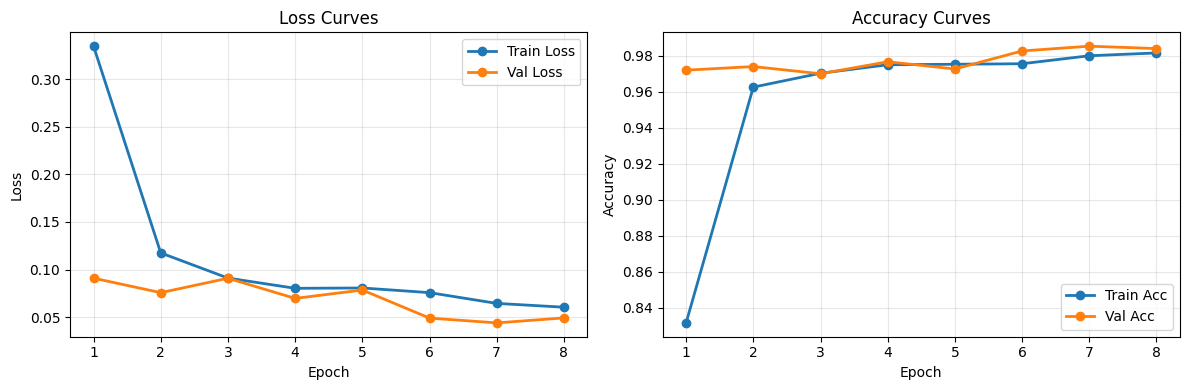

Saved: /Users/anton/Documents/GitHub/Final_Year_Project/runs/classical_baseline/notebook_run/training_curves.png


In [8]:
## 8. Train/Val loss and accuracy curves (same style as QCNN notebook)

epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 4), facecolor='white')

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], marker='o', label='Train Loss',  color='#1f77b4', linewidth=2)
plt.plot(epochs_range, history['val_loss'],   marker='o', label='Val Loss',    color='#ff7f0e', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves')
plt.legend(); plt.grid(alpha=0.3)
plt.gca().set_facecolor('white')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], marker='o', label='Train Acc',  color='#1f77b4', linewidth=2)
plt.plot(epochs_range, history['val_acc'],   marker='o', label='Val Acc',    color='#ff7f0e', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy Curves')
plt.legend(); plt.grid(alpha=0.3)
plt.gca().set_facecolor('white')

plt.tight_layout()
curves_path = OUT_DIR / 'training_curves.png'
plt.savefig(curves_path, dpi=250, bbox_inches='tight')
plt.show()
print(f'Saved: {curves_path}')


In [9]:
## 9. Evaluate on test set

best_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = best_model(images)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

test_acc = float((np.array(all_preds) == np.array(all_labels)).mean())
pos_probs = [row[1] for row in all_probs]
auc = roc_auc_score(all_labels, pos_probs)

print(f'Test Accuracy : {test_acc:.4f}')
print(f'ROC-AUC       : {auc:.4f}')
print()
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))


Test Accuracy : 0.9713
ROC-AUC       : 0.9970

Classification Report:
              precision    recall  f1-score   support

     cracked     0.9581    0.9834    0.9706       721
 not_cracked     0.9842    0.9602    0.9721       779

    accuracy                         0.9713      1500
   macro avg     0.9712    0.9718    0.9713      1500
weighted avg     0.9717    0.9713    0.9713      1500



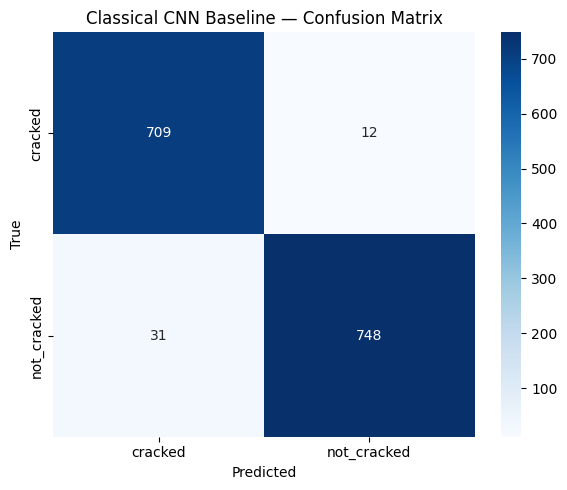

Saved: /Users/anton/Documents/GitHub/Final_Year_Project/runs/classical_baseline/notebook_run/confusion_matrix.png


In [10]:
## 10. Confusion matrix (same layout and labels as QCNN notebook)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Classical CNN Baseline — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
cm_path = OUT_DIR / 'confusion_matrix.png'
plt.savefig(cm_path, dpi=250, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')


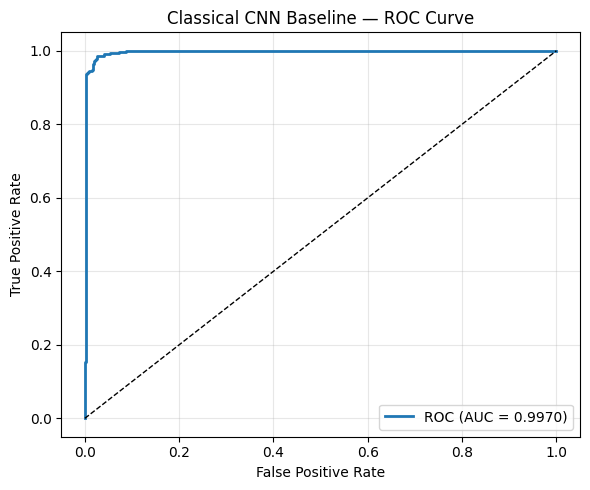

Saved: /Users/anton/Documents/GitHub/Final_Year_Project/runs/classical_baseline/notebook_run/roc_curve.png


In [11]:
## 11. ROC Curve

fpr, tpr, _ = roc_curve(all_labels, pos_probs)

plt.figure(figsize=(6, 5), facecolor='white')
plt.plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Classical CNN Baseline — ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.gca().set_facecolor('white')
plt.tight_layout()
roc_path = OUT_DIR / 'roc_curve.png'
plt.savefig(roc_path, dpi=250, bbox_inches='tight')
plt.show()
print(f'Saved: {roc_path}')


In [16]:
## 12. Save model checkpoint and metrics.json

# Model
model_path = OUT_DIR / 'best_classical_baseline.pt'
torch.save(best_model.state_dict(), model_path)

# Extract per-class metrics — positive class = 'cracked' (inspection-relevant convention)
report = classification_report(all_labels, all_preds,
                                target_names=classes, output_dict=True, zero_division=0)
POS_CLASS = classes[0]  # 'cracked'
precision = report[POS_CLASS]['precision']
recall    = report[POS_CLASS]['recall']
f1        = report[POS_CLASS]['f1-score']

# Metrics JSON
metrics_payload = {
    'model': 'ClassicalCNNBaseline',
    'subset_size': SUBSET_SIZE,
    'epochs': config.epochs,
    'device': device,
    'train_time_seconds': round(train_time, 2),
    'test_accuracy': round(test_acc, 6),
    'precision': round(precision, 6),
    'recall': round(recall, 6),
    'f1': round(f1, 6),
    'roc_auc': round(auc, 6),
    'total_params': count_parameters(best_model),
    'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist(),
    'classification_report': report,
    'history': history,
    'config': config.to_dict(),
}
metrics_path = OUT_DIR / 'metrics.json'
with open(metrics_path, 'w') as fh:
    json.dump(metrics_payload, fh, indent=2, default=str)

print(f'Model   : {model_path}')
print(f'Metrics : {metrics_path}')

# Verify nothing was written to runs/quantum_cnn/
qcnn_dir = PROJECT_ROOT / 'runs' / 'quantum_cnn'
assert str(qcnn_dir.resolve()) not in str(model_path.resolve()), \
    'Writing to wrong directory!'
print('✅ Confirmed: no files written into runs/quantum_cnn/')

print('\nDirectory listing of', OUT_DIR)
for p in sorted(OUT_DIR.iterdir()):
    print(f'  {p.name}')


Model   : /Users/anton/Documents/GitHub/Final_Year_Project/runs/classical_baseline/notebook_run/best_classical_baseline.pt
Metrics : /Users/anton/Documents/GitHub/Final_Year_Project/runs/classical_baseline/notebook_run/metrics.json
✅ Confirmed: no files written into runs/quantum_cnn/

Directory listing of /Users/anton/Documents/GitHub/Final_Year_Project/runs/classical_baseline/notebook_run
  best_classical_baseline.pt
  confusion_matrix.png
  metrics.json
  roc_curve.png
  training_curves.png


In [17]:
## 13. Head-to-head comparison table: QCNN vs Classical Baseline

import pandas as pd
from IPython.display import display

qcnn_metrics_path = PROJECT_ROOT / 'runs' / 'quantum_cnn' / 'notebook_run' / 'metrics.json'
qcnn = {}
if qcnn_metrics_path.exists():
    with open(qcnn_metrics_path) as fh:
        qcnn = json.load(fh)
    print(f'Loaded QCNN metrics from: {qcnn_metrics_path}')
else:
    print(f'⚠️  QCNN metrics.json not found at {qcnn_metrics_path}')
    print('   Run the QCNN notebook first to enable a full comparison.')

def _fmt(val, decimals=4):
    if val == 'N/A' or val is None:
        return 'N/A'
    try:
        return f'{float(val):.{decimals}f}'
    except (TypeError, ValueError):
        return str(val)

rows = [
    ['Total parameters',    f"{qcnn.get('total_params', 'N/A')}",
                            f"{metrics_payload['total_params']:,}"],
    ['Test Accuracy',       _fmt(qcnn.get('test_accuracy')),
                            _fmt(metrics_payload['test_accuracy'])],
    ['Precision',           _fmt(qcnn.get('precision')),
                            _fmt(metrics_payload['precision'])],
    ['Recall',              _fmt(qcnn.get('recall')),
                            _fmt(metrics_payload['recall'])],
    ['F1 Score',            _fmt(qcnn.get('f1')),
                            _fmt(metrics_payload['f1'])],
    ['ROC-AUC',             _fmt(qcnn.get('roc_auc')),
                            _fmt(metrics_payload['roc_auc'])],
    ['Training Time (s)',   f"{qcnn.get('train_time_seconds', 'N/A')}",
                            f"{metrics_payload['train_time_seconds']}"],
    ['Device',              qcnn.get('device', 'N/A'),
                            metrics_payload['device']],
]

df = pd.DataFrame(rows, columns=['Metric', 'QCNN (Hybrid)', 'Classical Baseline'])

def highlight_winner(row):
    higher_is_better = ['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
    lower_is_better  = ['Training Time (s)']
    styles = ['', '', '']
    metric = row['Metric']
    try:
        q = float(row['QCNN (Hybrid)'])
        c = float(row['Classical Baseline'])
        if metric in higher_is_better:
            if c > q:   styles[2] = 'background-color: #d4edda; font-weight: bold'
            elif q > c: styles[1] = 'background-color: #d4edda; font-weight: bold'
        elif metric in lower_is_better:
            if c < q:   styles[2] = 'background-color: #d4edda; font-weight: bold'
            elif q < c: styles[1] = 'background-color: #d4edda; font-weight: bold'
    except (TypeError, ValueError):
        pass
    return styles

styled = (df.style
    .apply(highlight_winner, axis=1)
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4A6FA5'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px'),
                                      ('border', '1px solid #ddd')]},
    ])
    .hide(axis='index')
)
display(styled)

print('\nGreen cells indicate the better value for that metric.')
print('NOTE: Precision / Recall / F1 use cracked as the positive class (inspection-relevant).')
print('NOTE: Optimizer used in BOTH models is torch.optim.Adam (from train_quantum_cnn.py),')
print('      not AdamW — ensures like-for-like training loop comparison.')


Loaded QCNN metrics from: /Users/anton/Documents/GitHub/Final_Year_Project/runs/quantum_cnn/notebook_run/metrics.json


Metric,QCNN (Hybrid),Classical Baseline
Total parameters,44878,"45,022"
Test Accuracy,0.9787,0.9713
Precision,0.9765,0.9581
Recall,0.9792,0.9834
F1 Score,0.9778,0.9706
ROC-AUC,0.9986,0.9970
Training Time (s),1096.2,111.75
Device,cpu,cpu



Green cells indicate the better value for that metric.
NOTE: Precision / Recall / F1 use cracked as the positive class (inspection-relevant).
NOTE: Optimizer used in BOTH models is torch.optim.Adam (from train_quantum_cnn.py),
      not AdamW — ensures like-for-like training loop comparison.
